# 🚀 Lab 46: Time Series Decomposition and Trend Analysis

## 🎯 Objectives
* Understand the fundamental concepts of time series decomposition.
* Load and prepare time series data with proper DateTime indexing.
* Resample time series data into weekly and monthly views.
* Apply seasonal decomposition to extract trend, seasonal, and residual components.
* Visualize and interpret decomposed time series components.
* Analyze energy consumption patterns and generate practical insights.

## 🧰 Prerequisites
* Basic Python (Pandas/NumPy).
* Familiarity with Matplotlib.
* Understanding of basic descriptive statistics.

## ⚙️ Environment Setup
### 🧒 ELI10
Before we start, we need to make sure our notebook has the right tools. These tools help us work with tables, dates, graphs, and time series models.

In [1]:
# Install necessary libraries
!pip install -q pandas numpy matplotlib seaborn statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

# Configuration
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

## 📥 Loading or Creating the Dataset
### 🧒 ELI10
Since we don't have an external file, we will create our own realistic dataset. We'll simulate 3 years of energy usage that grows over time (trend) and changes with the seasons.

**Why?** Creating synthetic data helps us understand exactly what signals go into the model.

In [3]:
# Set seed for reproducibility
np.random.seed(42)
start_date = "2021-01-01"
end_date = "2023-12-31"
date_range = pd.date_range(start=start_date, end=end_date, freq="D")
n_days = len(date_range)

# 1. Upward Trend
base_consumption = 100 + np.linspace(0, 20, n_days)

# 2. Yearly Seasonality
seasonal_pattern = (
    15 * np.sin(2 * np.pi * np.arange(n_days) / 365.25)
    + 10 * np.cos(4 * np.pi * np.arange(n_days) / 365.25)
)

# 3. Weekly Cycle
weekly_pattern = 5 * np.sin(2 * np.pi * np.arange(n_days) / 7)

# 4. Noise
noise = np.random.normal(0, 5, n_days)

# Combine
energy_consumption = base_consumption + seasonal_pattern + weekly_pattern + noise

energy_data = pd.DataFrame({
    "date": date_range,
    "energy_consumption": energy_consumption
})

print(f"Dataset Shape: {energy_data.shape}")
display(energy_data.head())

Dataset Shape: (1095, 2)


,date,energy_consumption
0,2021-01-01,112.483571
1,2021-01-02,113.488223
2,2021-01-03,118.641952
3,2021-01-04,120.559959
4,2021-01-05,107.669726


## 🔍 Data Exploration
Let's check the date range, missing values, and summary statistics to ensure our data is clean.

In [4]:
print(f"Date Range: {energy_data['date'].min()} to {energy_data['date'].max()}")
print(f"Observations: {len(energy_data)}")
print("\nMissing Values:")
print(energy_data.isnull().sum())
print("\nStatistics:")
display(energy_data.describe())

Date Range: 2021-01-01 00:00:00 to 2023-12-31 00:00:00
Observations: 1095

Missing Values:
date                  0
energy_consumption    0
dtype: int64

Statistics:


,date,energy_consumption
count,1095,1095.000000
mean,2022-07-02 00:00:00,110.166111
min,2021-01-01 00:00:00,66.561546
25%,2021-10-01 12:00:00,101.185113
50%,2022-07-02 00:00:00,112.030403
75%,2023-04-01 12:00:00,120.163395
max,2023-12-31 00:00:00,140.696979
std,NaN,14.176768


## 🕒 Time Index Preparation
### 🧒 ELI10
Time series tools work best when the date column is the index. It's like putting your data on a calendar instead of just a list.

**Result**: We'll have a DataFrame where the index is a `DatetimeIndex` with a daily frequency.

In [5]:
energy_data["date"] = pd.to_datetime(energy_data["date"])
energy_data = energy_data.set_index("date").sort_index()
energy_data = energy_data.asfreq("D")

print(f"Index Type: {type(energy_data.index)}")
print(f"Inferred Freq: {pd.infer_freq(energy_data.index)}")

Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Inferred Freq: D


## 🔁 Resampling for Different Perspectives
### 🧒 ELI10
Daily data is like looking at a single tree. Resampling to weeks or months is like zooming out to see the whole forest.

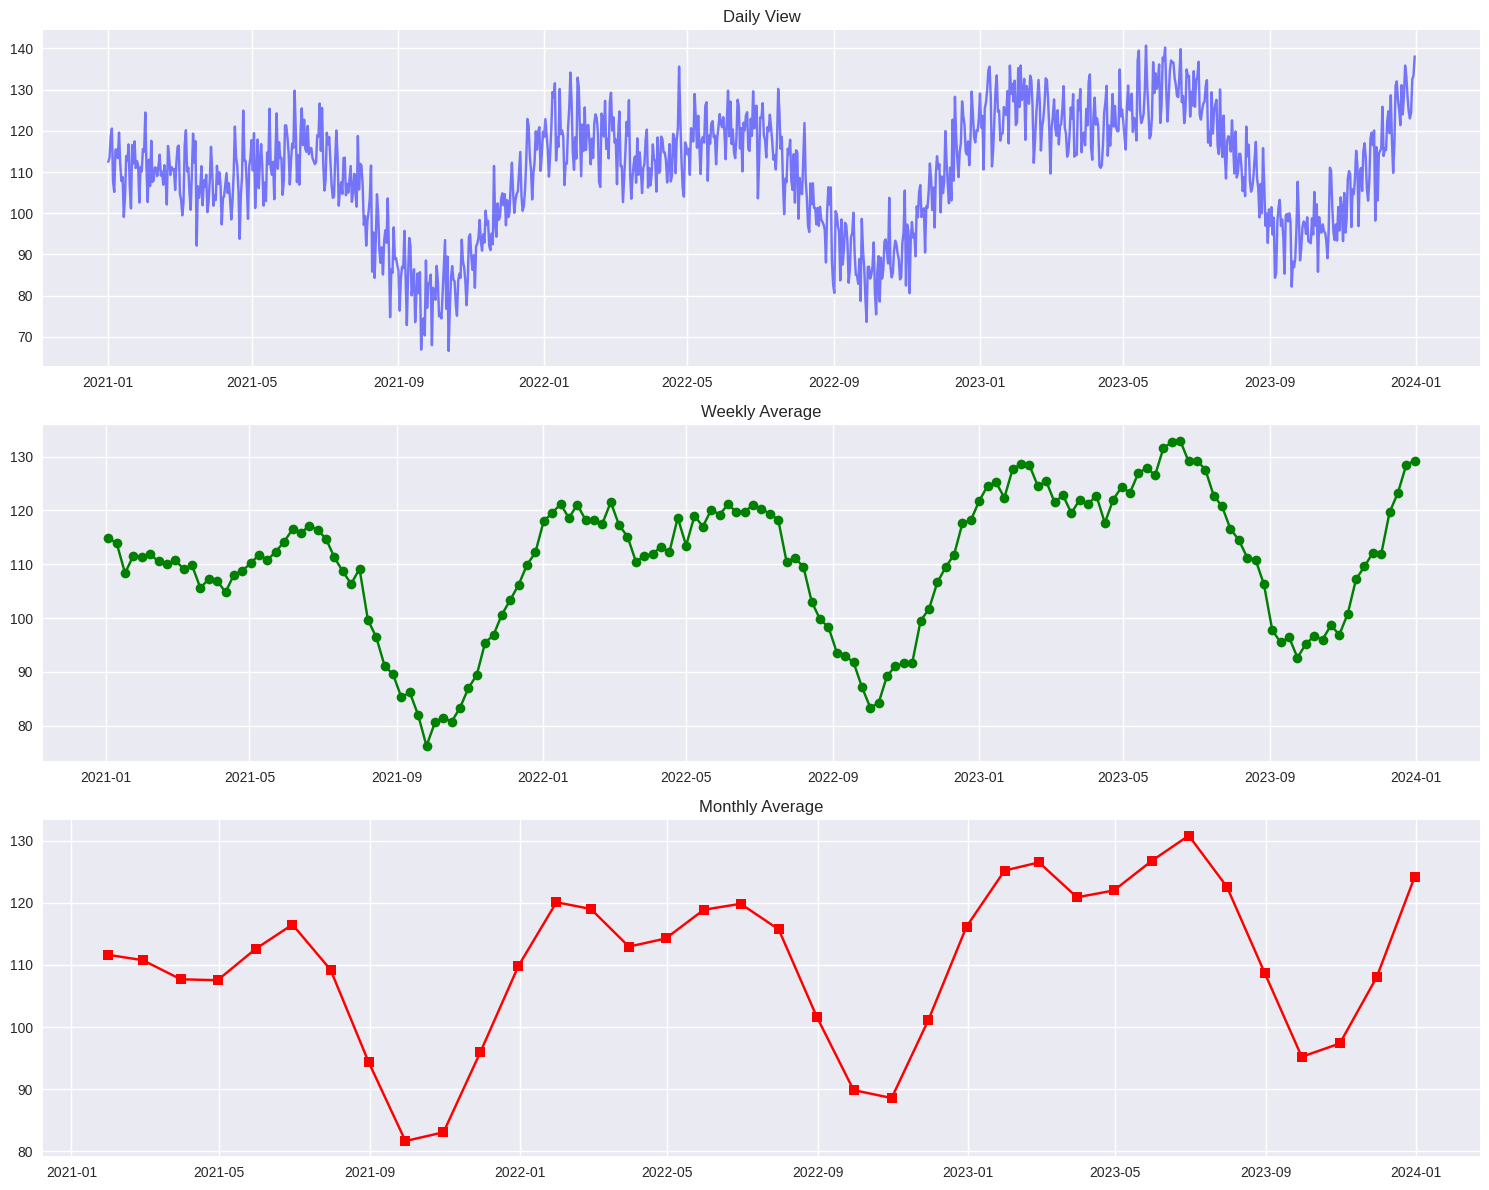

In [6]:
weekly_data = energy_data.resample("W").mean()
monthly_data = energy_data.resample("M").mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 12))
axes[0].plot(energy_data, color='blue', alpha=0.5)
axes[0].set_title("Daily View")
axes[1].plot(weekly_data, color='green', marker='o')
axes[1].set_title("Weekly Average")
axes[2].plot(monthly_data, color='red', marker='s')
axes[2].set_title("Monthly Average")
plt.tight_layout()
plt.show()

## 🧩 Seasonal Decomposition
### 🧒 ELI10
We are going to take the data apart into four pieces:
1. **Observed**: The actual data.
2. **Trend**: The slow growth over years.
3. **Seasonal**: The repeating cycles (like hot summers).
4. **Residual**: The random accidents or noise.

In [7]:
# Daily decomposition (Yearly period = 365)
decomposition_daily = seasonal_decompose(
    energy_data["energy_consumption"],
    model="additive",
    period=365
)

# Monthly decomposition (Yearly period = 12)
decomposition_monthly = seasonal_decompose(
    monthly_data["energy_consumption"],
    model="additive",
    period=12
)

# Extract components
observed_daily, trend_daily, seasonal_daily, residual_daily = decomposition_daily.observed, decomposition_daily.trend, decomposition_daily.seasonal, decomposition_daily.resid
observed_monthly, trend_monthly, seasonal_monthly, residual_monthly = decomposition_monthly.observed, decomposition_monthly.trend, decomposition_monthly.seasonal, decomposition_monthly.resid

## 📈 Visualization and Component Analysis
Let's visualize the decomposition for both Daily and Monthly data.

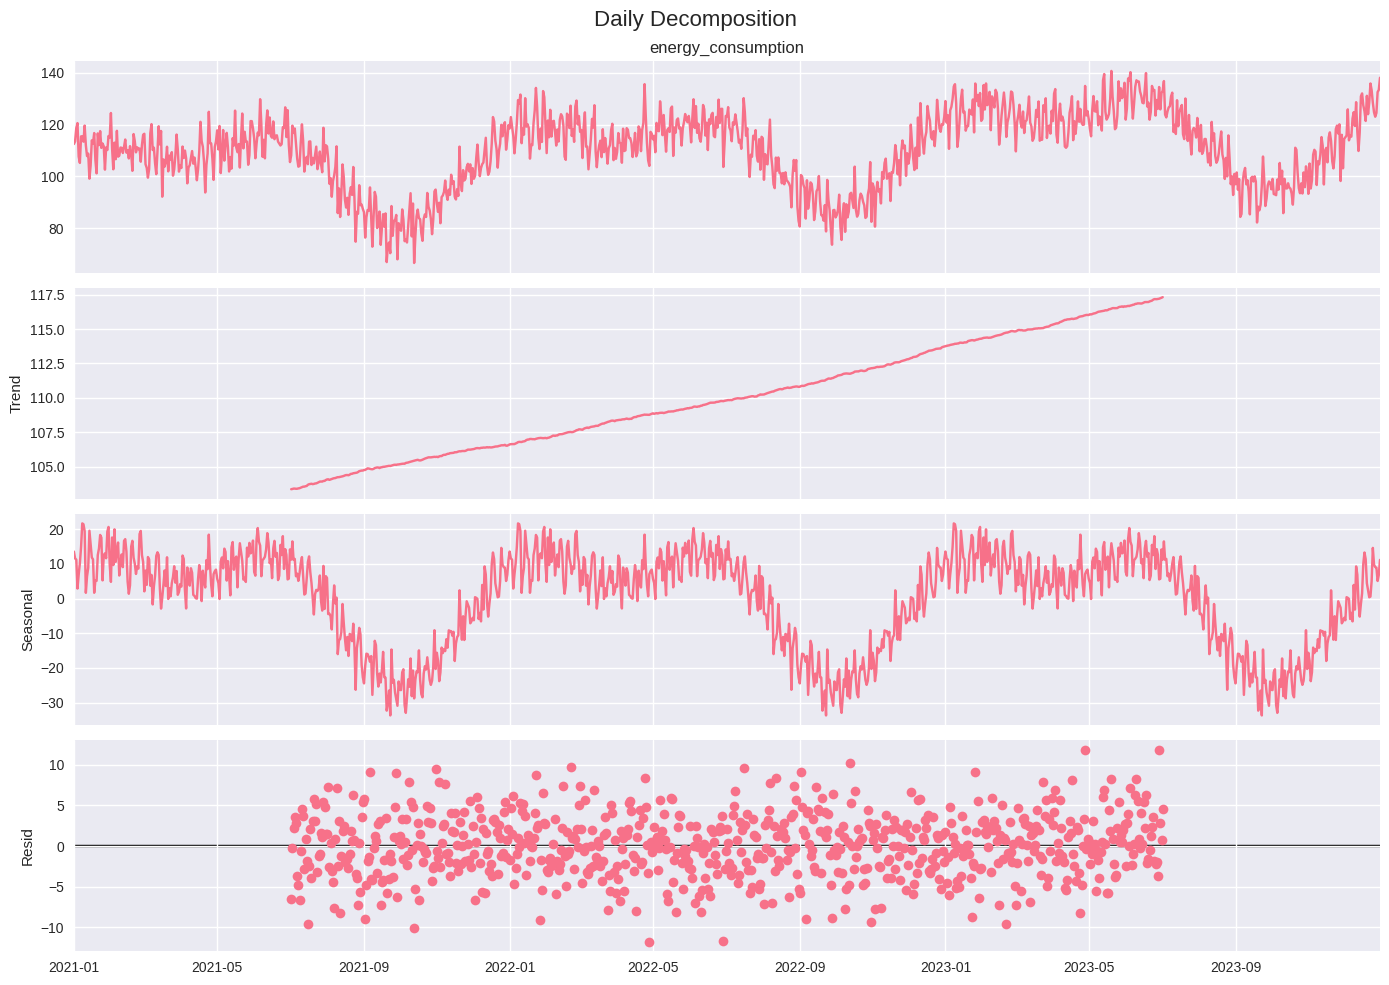

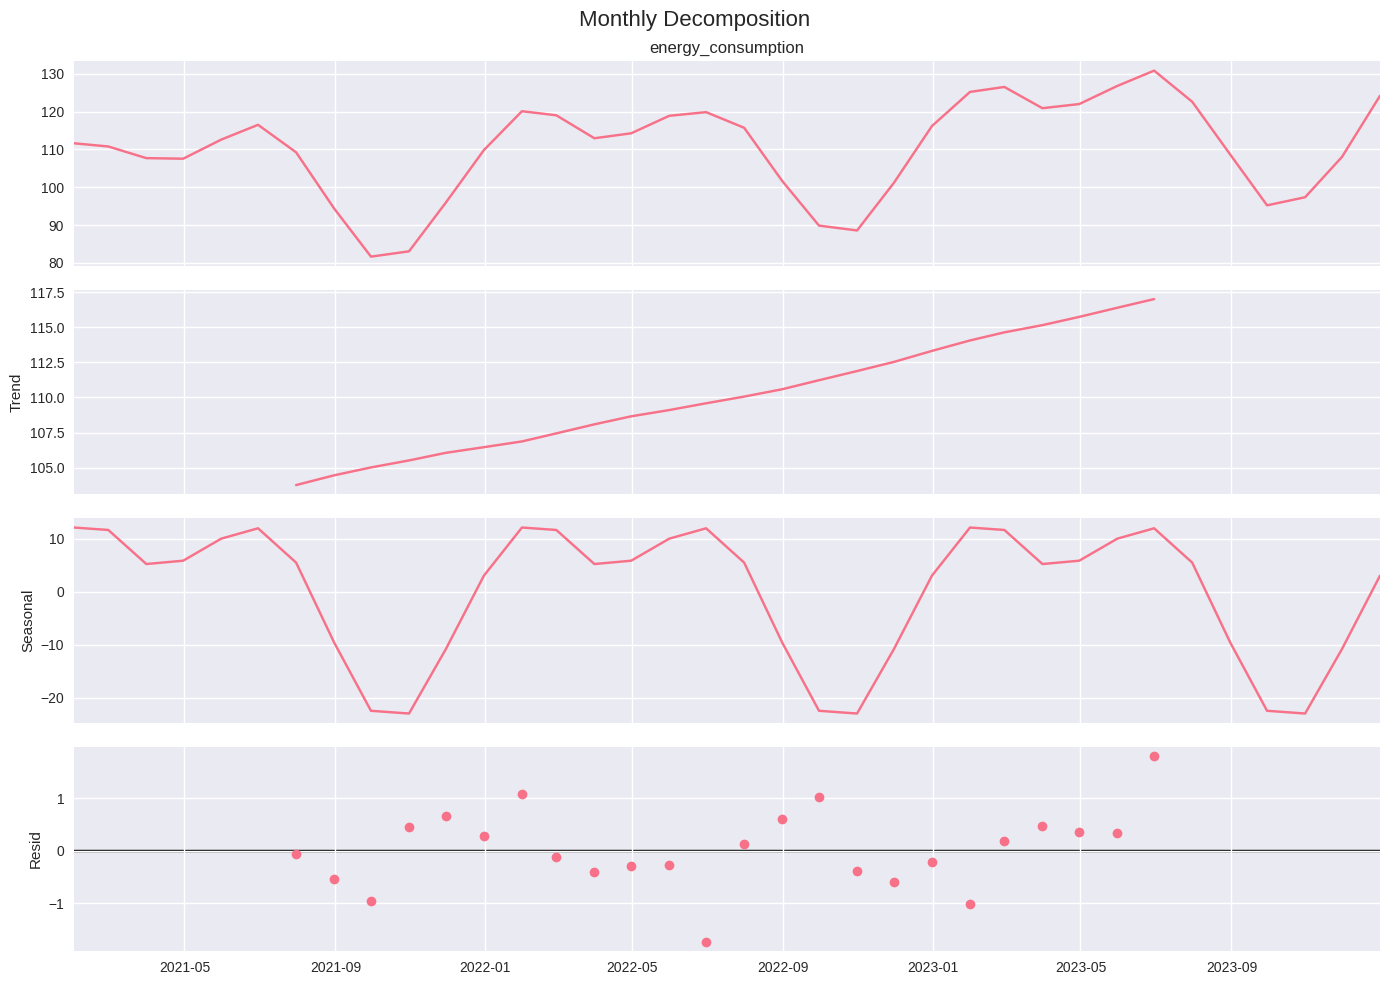

In [8]:
def plot_decomp(decomp, title):
    fig = decomp.plot()
    fig.set_size_inches(14, 10)
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_decomp(decomposition_daily, "Daily Decomposition")
plot_decomp(decomposition_monthly, "Monthly Decomposition")

## 📊 Trend Analysis
We calculate how much the base consumption grew from start to finish.

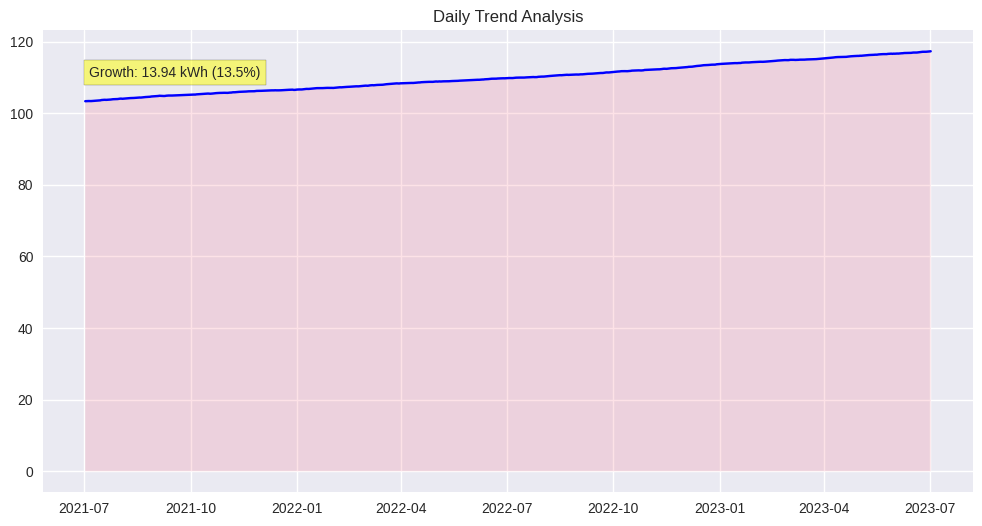

In [9]:
trend_start = trend_daily.dropna().iloc[0]
trend_end = trend_daily.dropna().iloc[-1]
trend_change = trend_end - trend_start
trend_change_percent = (trend_change / trend_start) * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(trend_daily, color='blue', label='Trend Line')
ax.fill_between(trend_daily.index, trend_daily, alpha=0.2)
ax.set_title("Daily Trend Analysis")
ax.text(0.05, 0.9, f"Growth: {trend_change:.2f} kWh ({trend_change_percent:.1f}%)",
        transform=ax.transAxes, bbox=dict(facecolor='yellow', alpha=0.5))
plt.show()

## 🧪 Interpretation and Insights
### 🧒 ELI10
This is where we become detectives. We look at the numbers to tell a story about energy use.

**What to expect**: Higher usage in specific months and a steady rise due to expansion.

In [10]:
seasonal_range = seasonal_daily.max() - seasonal_daily.min()
residual_std = residual_daily.std()
observed_std = observed_daily.std()
explained_percent = (1 - residual_std / observed_std) * 100

trend_contribution = (trend_daily.std() / observed_std) * 100
seasonal_contribution = (seasonal_daily.std() / observed_std) * 100

print("Summary Report")
print("-"*20)
print(f"Trend Contribution: {trend_contribution:.1f}%")
print(f"Seasonal Contribution: {seasonal_contribution:.1f}%")
print(f"Predictability Score: {explained_percent:.1f}%")

Summary Report
--------------------
Trend Contribution: 28.0%
Seasonal Contribution: 95.8%
Predictability Score: 72.8%


## ✅ Verification
We verify that all required objects exist and are populated.

In [11]:
checks = {
    "Data exists": isinstance(energy_data, pd.DataFrame),
    "Index is DateTime": isinstance(energy_data.index, pd.DatetimeIndex),
    "Decomposition Complete": trend_daily.notnull().any()
}
for k, v in checks.items():
    print(f"{k}: {'✅' if v else '❌'}")

Data exists: ✅
Index is DateTime: ✅
Decomposition Complete: ✅


## 🛠 Troubleshooting
### 🧒 ELI10
What if the data is broken?
1. **Missing values**: Use `.interpolate()` to fill gaps.
2. **Wrong Model**: Use 'Multiplicative' if the ups and downs get bigger as the values get higher.

In [12]:
# Example: Handling Positive Shift for Multiplicative Model
positive_series = energy_data["energy_consumption"].copy()
positive_series = positive_series - positive_series.min() + 1

decomp_mult = seasonal_decompose(positive_series, model="multiplicative", period=365)
print("Multiplicative model calculated safely.")

Multiplicative model calculated safely.


## 📚 Key Takeaways
* Decomposition is a superpower for seeing through noise.
* Trend shows growth, Seasonality shows cycles.
* Use resampling to clean up messy daily data.

## 🌍 Real-World Importance
Companies use this to predict how much electricity to buy for next winter or how many items to stock for the holiday rush.

## 🏁 Conclusion
You have successfully built a full time-series analysis pipeline from scratch! You can now apply these techniques to any time-based data like sales, weather, or stock prices.